# Batch Photometry Demo

This notebook demonstrates the `spxquery.batch` module for extracting multi-source aperture photometry from SPHEREx full-frame images.

**Workflow:**
1. Prepare a source catalog (CSV with `targetid`, `ra`, `dec`)
2. Query IRSA TAP for full-frame images covering a sky region
3. Download the images
4. Extract photometry for all sources in each image's FOV
5. Aggregate into per-source light curves
6. Inspect results

**Key parameters for narrowing the search:**
- `bands`: Filter by detector band (D1–D6)
- `mjd_range`: Filter by time window `(mjd_min, mjd_max)`
- `coverage_mode`: `"full"` = region fully inside image; `"any"` = partial overlap

In [1]:
import sys
from pathlib import Path

# Ensure spxquery from this repo is importable
sys.path.insert(0, str(Path("../../src").resolve()))

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from spxquery.batch import BatchConfig, BatchPipeline
from spxquery.batch.config import load_catalog
from spxquery.core.config import PhotometryConfig, Source

## 1. Prepare a Source Catalog

We create a small catalog of known sources around the NEP (North Ecliptic Pole) region. In practice, you would load an existing catalog from DESI, SDSS, or your own observations.

In [2]:
# Demo directory and output
DEMO_DIR = Path(".").resolve()
OUTPUT_DIR = DEMO_DIR / "batch_output"

# Real DESI NEP sources with verified coordinates from the SPHEREx initial sample catalog
catalog_data = {
    "targetid": [
        39633458737186280,
        39633458737186872,
        39633458737187232,
        39633458737187440,
        39633456304492080,
        39633458741379432,
        39633456304490936,
        39633461140523944,
    ],
    "ra": [269.936892, 270.035133, 270.093226, 270.129665, 269.934474, 270.354796, 269.752464, 269.917500],
    "dec": [66.486330, 66.533071, 66.554050, 66.593843, 66.356651, 66.604006, 66.317337, 66.732800],
}

catalog_df = pd.DataFrame(catalog_data)
catalog_path = DEMO_DIR / "demo_catalog.csv"
catalog_df.to_csv(catalog_path, index=False)

print(f"Catalog: {len(catalog_df)} sources")
print(f"  RA range:  {catalog_df['ra'].min():.4f} - {catalog_df['ra'].max():.4f}")
print(f"  Dec range: {catalog_df['dec'].min():.4f} - {catalog_df['dec'].max():.4f}")
catalog_df

Catalog: 8 sources
  RA range:  269.7525 - 270.3548
  Dec range: 66.3173 - 66.7328


,targetid,ra,dec
0,39633458737186280,269.936892,66.486330
1,39633458737186872,270.035133,66.533071
2,39633458737187232,270.093226,66.554050
3,39633458737187440,270.129665,66.593843
4,39633456304492080,269.934474,66.356651
5,39633458741379432,270.354796,66.604006
6,39633456304490936,269.752464,66.317337
7,39633461140523944,269.917500,66.732800


## 2. Configure and Run the Pipeline

`BatchConfig` defines the sky region, catalog, and processing parameters.

To keep this demo manageable (~18 images, ~1.3 GB), we filter by:
- **Band**: D3 only (1.63–2.41 $\mu$m)
- **MJD range**: A 2-day window
- **Coverage**: `"full"` — only images that fully contain the search circle

For production use, set `bands=None` and `mjd_range=None` to process all epochs and bands.

In [3]:
config = BatchConfig(
    center_ra=270.0,
    center_dec=66.6,
    radius=0.3,                        # Degrees — small for demo
    catalog_path=catalog_path,
    output_dir=OUTPUT_DIR,
    coverage_mode="full",              # Region fully inside image
    bands=["D3"],                      # Single band for demo
    mjd_range=(60791.0, 60793.0),      # 2-day window (~18 images)
    max_images=50,                     # Safety cap
    max_download_workers=4,
    max_extract_workers=4,
    photometry=PhotometryConfig(
        aperture_method="fwhm",
        fwhm_multiplier=2.5,
        background_method="window",
        window_size=30,
        subtract_zodi=True,
    ),
)

print(f"Region: RA={config.center_ra}, Dec={config.center_dec}, radius={config.radius} deg")
print(f"Bands: {config.bands}")
print(f"MJD range: {config.mjd_range}")
print(f"Coverage: {config.coverage_mode}")
print(f"Output: {config.output_dir}")

Region: RA=270.0, Dec=66.6, radius=0.3 deg
Bands: ['D3']
MJD range: (60791.0, 60793.0)
Coverage: full
Output: /Users/wenke/data/20250805SPHEREX/spxquery/example/batch_demo/batch_output


In [4]:
pipeline = BatchPipeline(config)

### Stage 1: Query

In [5]:
query_results = pipeline.run_query()

print(f"\nFound {len(query_results)} observations")
print(f"Estimated download: ~{len(query_results) * 0.07:.1f} GB")
print("Bands:")
for band, count in sorted(query_results.band_counts.items()):
    print(f"  {band}: {count} images")


Found 18 observations
Estimated download: ~1.3 GB
Bands:
  D3: 18 images


In [6]:
# The query summary is automatically saved to query_summary.yaml
from spxquery.batch import load_query_summary

summary = load_query_summary(config.output_dir)
print(yaml.dump({k: v for k, v in summary.items() if k != "observations"}, default_flow_style=False))
print(f"Observations: {len(summary['observations'])} (first 3 shown)")
for obs in summary["observations"][:3]:
    print(f"  {obs['obs_id']}  {obs['band']}  MJD={obs['mjd']:.2f}  λ={obs['wavelength_um']:.3f} μm")

band_counts:
  D3: 18
filters:
  bands:
  - D3
  mjd_range:
  - 60791.0
  - 60793.0
n_observations: 18
query_time: '2026-05-18T17:05:25.230633'
region:
  center_dec: 66.6
  center_ra: 270.0
  coverage_mode: full
  radius_deg: 0.3
time_span_days: 0.7534636225027498

Observations: 18 (first 3 shown)
  2025W17_4B_0277_1  D3  MJD=60791.58  λ=2.032 μm
  2025W17_4B_0277_2  D3  MJD=60791.58  λ=2.032 μm
  2025W17_4B_0277_3  D3  MJD=60791.58  λ=2.032 μm


### Stage 2: Download

Full-frame images (~71.6 MB each).

In [7]:
download_results = pipeline.run_download(skip_existing=True)

n_success = sum(1 for r in download_results if r.success)
print(f"\nDownloaded {n_success}/{len(download_results)} images")

Downloading: 100%|██████████| 18/18 [00:00<00:00, 10796.15files/s]


Download Summary
Total files: 18
Successful: 18
Failed: 0
Total downloaded: 1229.7 MB (1.20 GB)


Downloaded 18/18 images


### Stage 3: Extract Photometry

For each image, the pipeline:
1. Reads the MEF file once
2. Projects all catalog sources to pixel coordinates via WCS
3. Filters to sources within the field of view
4. Extracts aperture photometry for each in-FOV source
5. Saves results as a per-image CSV (incremental / resumable)

In [8]:
n_new = pipeline.run_extract(skip_existing=True)
print(f"\nExtracted {n_new} per-image CSVs")

Extracting photometry:   0%|          | 0/18 [00:00<?, ?image/s]


Extracted 18 per-image CSVs


### Stage 4: Aggregate Light Curves

Combines per-image CSVs into per-source light curves using a memory-efficient bucket-based approach.

In [9]:
n_sources = pipeline.run_aggregate(clean=True)
print(f"\nCreated {n_sources} light curve files")

Bucketing CSVs:   0%|          | 0/18 [00:00<?, ?file/s]

Writing lightcurves:   0%|          | 0/7 [00:00<?, ?bucket/s]


Created 8 light curve files


## 3. Inspect Results

In [10]:
# List all light curve files
lc_files = sorted(config.lightcurve_dir.glob("*.csv"))
print(f"Light curves: {len(lc_files)} files")

# Show directory structure
print(f"\nOutput structure:")
print(f"  {config.output_dir}/")
print(f"    images/          — {len(list(config.image_dir.rglob('*.fits')))} FITS files")
print(f"    per_image/       — {len(list(config.per_image_dir.glob('*.csv')))} CSV files")
print(f"    lightcurves/     — {len(lc_files)} CSV files")

Light curves: 8 files

Output structure:
  /Users/wenke/data/20250805SPHEREX/spxquery/example/batch_demo/batch_output/
    images/          — 18 FITS files
    per_image/       — 18 CSV files
    lightcurves/     — 8 CSV files


In [11]:
# Load and display a sample light curve
if lc_files:
    sample = lc_files[0]
    lc = pd.read_csv(sample)
    print(f"Sample: {sample.name} — {len(lc)} observations")
    display(lc.head(10))

Sample: 39633456304490936.csv — 18 observations


,obs_id,band,mjd,x,y,flux,flux_error,mag_ab,mag_ab_error,wavelength,bandwidth,flag,bg_level,bg_error,aperture_radius
0,2025W17_4B_0277_1,D3,60791.575317,864.391922,1710.515466,92.958835,26.377949,18.979273,0.308088,1.726968,0.041594,524288,0.589002,0.014259,1.060629
1,2025W17_4B_0277_2,D3,60791.576809,865.296370,1595.691277,67.103672,23.516700,19.333134,0.380500,1.766791,0.043033,0,0.530335,0.013513,1.060503
2,2025W17_4B_0277_3,D3,60791.578319,865.722178,1480.870581,60.547623,22.673364,19.444757,0.406577,1.808392,0.044435,524288,0.538649,0.013357,1.060681
3,2025W17_4B_0277_4,D3,60791.579812,865.832396,1366.102081,32.655447,21.906908,20.115111,0.728366,1.850682,0.045822,655360,0.620814,0.012720,1.060792
4,2025W17_4B_0287_3,D3,60791.646323,862.543543,1023.263765,83.238938,22.114106,19.099184,0.288448,1.982031,0.048888,524288,0.542117,0.012057,1.060754
5,2025W17_4B_0287_4,D3,60791.647816,863.450878,907.861127,72.031906,47.870081,19.256188,0.721545,2.027914,0.050378,0,0.611700,0.012452,1.060549
6,2025W17_4B_0298_1,D3,60791.713137,863.828405,1253.911620,57.942578,23.157962,19.492505,0.433937,1.892958,0.046839,524288,0.653566,0.013261,1.060562
7,2025W17_4B_0298_2,D3,60791.714630,864.601456,1138.785212,92.098512,22.457431,18.989368,0.264747,1.936873,0.047670,524288,0.548915,0.012836,1.060615
8,2025W17_4B_0298_3,D3,60791.716122,864.895693,1023.722153,53.623075,21.679876,19.576621,0.438964,1.981836,0.048880,524288,0.549315,0.012777,1.060616
9,2025W17_4B_0298_4,D3,60791.717614,864.888957,908.630017,-49.391879,28.526469,NaN,NaN,2.027600,0.050369,524293,0.632661,0.012918,1.060588


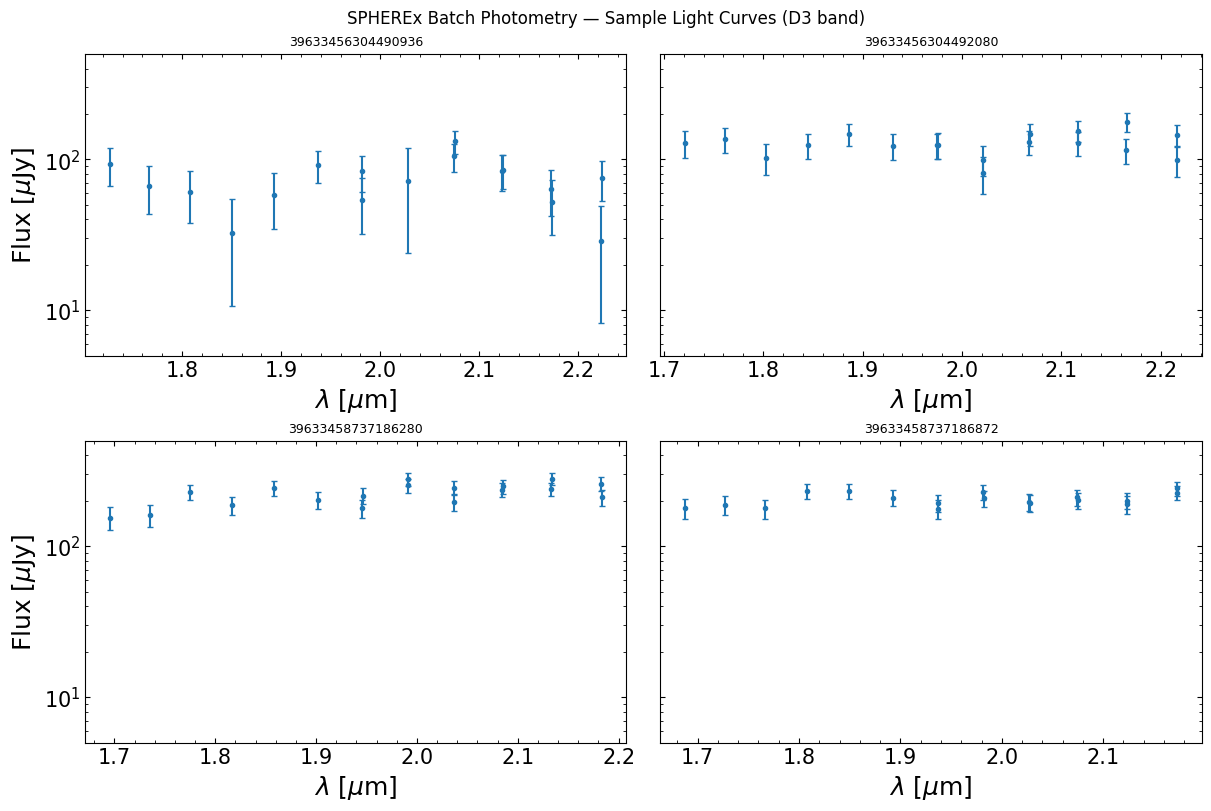

In [15]:
# Spectral view: flux vs wavelength for sources with multiple observations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

plotted = 0
for lc_file in lc_files:
    lc = pd.read_csv(lc_file)
    if len(lc) < 2:
        continue
    if plotted >= 4:
        break

    ax = axes[plotted]
    target_id = lc_file.stem

    ax.errorbar(
        lc["wavelength"],
        lc["flux"],
        yerr=lc["flux_error"],
        fmt="o",
        markersize=3,
        capsize=2,
        color="tab:blue",
    )

    ax.set_title(f"{target_id}", fontsize=9)
    ax.set_xlabel(r"$\lambda$ [$\mu$m]")
    if plotted % 2 == 0:
        ax.set_ylabel(r"Flux [$\mu$Jy]")
    ax.set_ylim(5, 500)  # Avoid log(0) issues
    ax.set_yscale("log")
    plotted += 1

# Hide unused axes
for i in range(plotted, 4):
    axes[i].set_visible(False)

fig.suptitle("SPHEREx Batch Photometry — Sample Light Curves (D3 band)", fontsize=12)
plt.show()

## 4. Alternative: One-Line Execution

For production use, you can run the entire pipeline with a single function call:

In [13]:
from spxquery.batch import run_batch

# This runs all four stages: query -> download -> extract -> aggregate
# Uncomment to execute:

# pipeline = run_batch(
#     catalog="demo_catalog.csv",
#     center_ra=270.0,
#     center_dec=66.6,
#     radius=0.3,
#     output_dir="batch_output_v2",
#     coverage_mode="full",
#     bands=["D3"],
#     mjd_range=(60791.0, 60793.0),
#     max_images=50,
#     max_extract_workers=4,
# )

## Notes

- **Incremental processing:** Stages 2 and 3 are resumable. Re-running with `skip_existing=True` skips already-processed files.
- **Size gate:** `max_images` prevents accidental large downloads. Increase it if you know what you're doing.
- **Coverage modes:** `"full"` ensures the search circle is entirely inside each image (recommended for photometry). `"any"` includes images with partial overlap.
- **Time filtering:** Use `mjd_range=(mjd_min, mjd_max)` to select specific epochs. `None` = all time.
- **Band filtering:** Use `bands=["D1", "D3"]` to select specific detectors. `None` = all bands.
- **Memory:** Aggregation uses a bucket-based approach that never loads the full dataset into memory.